# Linear Inverse Problem: MNIST Deblurring via Bridge Flow Matching

This notebook implements and evaluates **Image-to-Image Bridge Flow Matching** on a toy
linear inverse problem:

$$y = Ax + e, \quad A = \text{Gaussian blur},\quad e \sim \mathcal{N}(0, \sigma^2 I)$$

Given a blurry, noisy observation $y$, the model learns to recover the clean image $x$.

**Key idea**: instead of flowing from Gaussian noise to data, the ODE flows directly
from $y$ (the degraded input) to $x$ (the clean target).  The only change relative to the
standard OT-CFM training loop is replacing `x0 ~ N(0,I)` with `x0 = y`.

**Reference**: I²SB — Image-to-Image Schrödinger Bridge (Liu et al., arXiv:2302.05872)

**Outline**
1. Setup — config, GPU, model
2. Forward model — visualise blurring + noise
3. Training — bridge flow matching on paired (y, x) data
4. Inference — ODE integration from y to x̂
5. Evaluation — visual grid, trajectory, posterior samples, PSNR/SSIM, ablations

## 1. Setup

In [3]:
import jax
import optax
import numpy as np
import jax.numpy as jnp
import jax.random as jr
import sys
import os
sys.path.append(os.path.abspath("../.."))

import src.train.trainer as tr
import src.flow.otfm as otfm

from src.model.unet import UNet
from src.data.mnist_inverse import make_paired_loader
from src.flow.bridge import sample_bridge, sample_bridge_trajectory
from hydra import compose, initialize


# --- GPU setup ---
try:
    gpu = jax.devices("gpu")[0]
    jax.config.update("jax_default_device", gpu)
    print(f"Using GPU: {gpu}")
except RuntimeError:
    print("No GPU found — running on CPU:", jax.devices("cpu")[0])
print("All devices:", jax.devices())

# --- Config ---
with initialize(version_base=None, config_path="../../configs", job_name="jupyter_inv"):
    cfg = compose(
        config_name="config",
        overrides=[
            "model.base_channels=64",
            "model.channel_multipliers=[1,2,4,8]",
            "model.num_groups=8",
            "model.num_heads=8",
        ]
    )

# Forward model parameters
SIGMA_BLUR  = 2.0
SIGMA_NOISE = 0.05
BATCH_SIZE  = 128
LR          = 1e-4

key = jr.PRNGKey(cfg.seed)
model_key, key = jr.split(key)
model = UNet(key=model_key, **cfg.model)
optim = optax.adamw(LR)
state = tr.make_train_state(model, optim)
train_step = tr.make_train_step(optim)
t_min = float(cfg.flow.otfm.t_min)
t_max = float(cfg.flow.otfm.t_max)

Using GPU: cuda:0
All devices: [CudaDevice(id=0)]


## 2. Forward Model — Gaussian Blur as a Linear Operator

The forward operator $A$ is a 2D Gaussian convolution with $\sigma = 2$ pixels applied to
each 28×28 image.  Convolution is a linear operation; in matrix form $A$ is a banded
Toeplitz-like matrix of size $784 \times 784$, but we apply it efficiently as a separable
filter via `scipy.ndimage.gaussian_filter`.

Additive noise $e \sim \mathcal{N}(0, 0.05^2 I)$ is then added (in the $[-1,1]$ normalised
scale this is about 2.5% RMS noise), giving the final degraded observation $y$.

The cell below shows 8 examples side-by-side: **clean** $x$ (top) vs **degraded** $y$ (bottom).

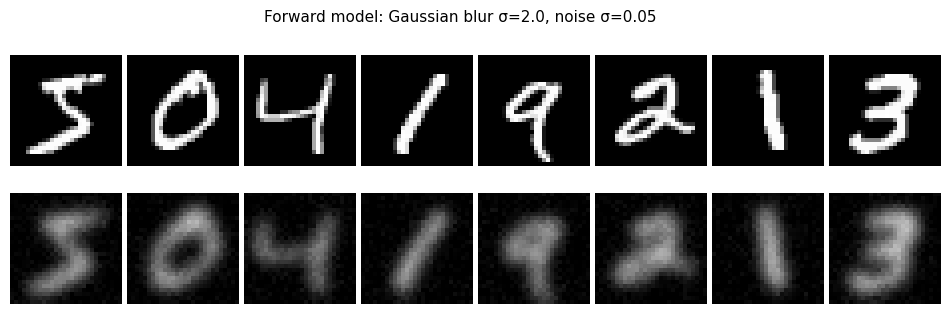

In [14]:
import matplotlib.pyplot as plt
from src.data.mnist_inverse import BlurredMNIST

preview_ds = BlurredMNIST(train=True, sigma_blur=SIGMA_BLUR, sigma_noise=SIGMA_NOISE, seed=0)

N_PREVIEW = 8
fig, axes = plt.subplots(2, N_PREVIEW, figsize=(N_PREVIEW * 1.5, 3.5),
                         gridspec_kw={"hspace": 0.05, "wspace": 0.05})

for col in range(N_PREVIEW):
    y, x1 = preview_ds[col]
    # Rescale [-1,1] → [0,1] for display
    x1_disp = (x1.numpy()[0] + 1) / 2
    y_disp  = (y.numpy()[0]  + 1) / 2

    axes[0, col].imshow(x1_disp, cmap="gray", vmin=0, vmax=1)
    axes[0, col].axis("off")
    axes[1, col].imshow(y_disp,  cmap="gray", vmin=0, vmax=1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("clean x",    fontsize=9, rotation=0, labelpad=40)
axes[1, 0].set_ylabel("degraded y", fontsize=9, rotation=0, labelpad=40)
fig.suptitle(f"Forward model: Gaussian blur σ={SIGMA_BLUR}, noise σ={SIGMA_NOISE}", fontsize=11)
plt.show()

## 3. Training — Bridge Flow Matching

The training loop is identical to the standard OT-CFM loop with one change:

| | Standard OT-CFM | Bridge FM (this notebook) |
|---|---|---|
| **x₀** | `x0 ~ N(0, I)` — random noise | `x0 = y` — the degraded observation |
| **x₁** | Clean image from dataset | Clean image from dataset |
| **OT coupling** | Pairs noise with data | Pairs degraded images with clean images |
| **Path** | `x_t = (1−t)·x0 + t·x1` | Same formula, but x0 is now y |
| **Velocity target** | `u_t = x1 − x0` | Same — now the residual from y to x |
| **Loss** | MSE(v_θ(t, x_t), u_t) | Unchanged |

The model implicitly learns the conditional distribution $p(x|y)$: the OT coupling within
each batch pairs similar degraded images with similar clean images (e.g. blurry-3 with sharp-3),
so the velocity field learns to transport each observation to its corresponding clean counterpart.

In [15]:
trainloader = make_paired_loader(
    split="train", batch_size=BATCH_SIZE,
    sigma_blur=SIGMA_BLUR, sigma_noise=SIGMA_NOISE, seed=cfg.seed
)
testloader = make_paired_loader(
    split="test", batch_size=BATCH_SIZE,
    sigma_blur=SIGMA_BLUR, sigma_noise=SIGMA_NOISE, seed=cfg.seed + 1
)
print(f"Train batches: {len(trainloader)},  Test batches: {len(testloader)}")

Train batches: 469,  Test batches: 79


In [16]:
num_epochs = 5

for epoch in range(num_epochs):
    for step, (y_batch, x1_batch) in enumerate(trainloader):
        x1_np = x1_batch.numpy()           # (B, 1, 28, 28)  clean
        y_np  = y_batch.numpy()            # (B, 1, 28, 28)  degraded  ← x0 for bridge
        B = x1_np.shape[0]

        key, subkey = jax.random.split(key)
        cpu_seed = int(jax.random.randint(subkey, shape=(), minval=0, maxval=2**31 - 1))
        rng = np.random.default_rng(cpu_seed)

        # Bridge: x0 = y (degraded image), NOT random noise
        t_np = rng.uniform(t_min, t_max, size=(B,)).astype(np.float32)
        x0_paired = otfm.minibatch_ot_coupling(y_np, x1_np)   # OT pairs y with x1

        x0 = jnp.array(x0_paired)
        x1 = jnp.array(x1_np)
        t  = jnp.array(t_np)

        state, loss = train_step(state, x0, x1, t)

    print(f"epoch={epoch}  loss={float(loss):.6f}")

2026-03-18 01:15:33.237025: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-18 01:15:33.237093: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-18 01:15:33.237152: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-18 01:15:33.237166: W external/xla/xla/service/gpu/au

epoch=0  loss=0.006523
epoch=1  loss=0.004834
epoch=2  loss=0.005048
epoch=3  loss=0.003827
epoch=4  loss=0.004379


## 4. Inference

Generating a reconstruction from a degraded image $y$ is simply:

$$\frac{dx}{dt} = v_\theta(t,\, x), \quad x(0) = y$$

The initial condition is the degraded observation rather than noise.  All other aspects
of the ODE solver (`diffrax.Euler`, 100 steps) are unchanged.  `sample_bridge` and
`sample_bridge_trajectory` in `src/flow/bridge.py` implement this.

### 4a. Visual grid: degraded | reconstructed | clean

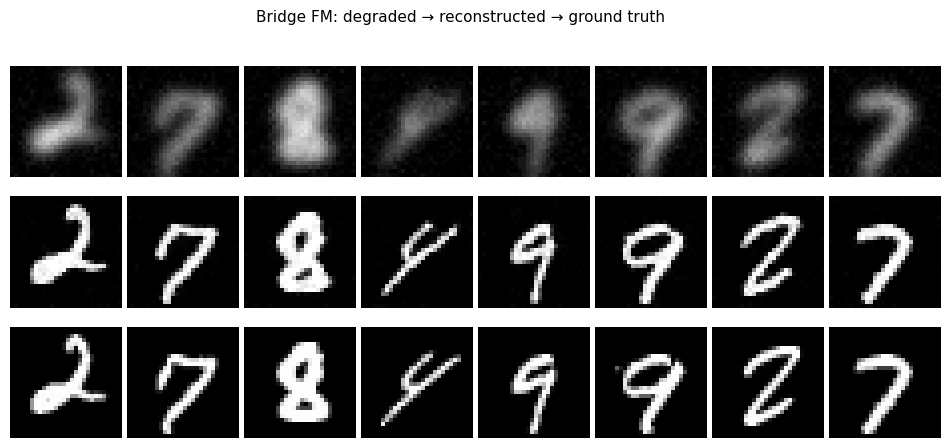

In [17]:
import diffrax

trained_model = state.model
solver = diffrax.Euler()
controller = diffrax.ConstantStepSize()
dt0 = float(cfg.flow.sample.dt0)
t0  = float(cfg.flow.sample.t0)
t1  = float(cfg.flow.sample.t1)

# Grab one test batch
y_test_batch, x1_test_batch = next(iter(testloader))
y_test_np  = y_test_batch.numpy()[:8]     # (8, 1, 28, 28)
x1_test_np = x1_test_batch.numpy()[:8]

# Reconstruct each y
recons = []
for i in range(8):
    y_i = jnp.array(y_test_np[i])         # (1, 28, 28)
    xhat = sample_bridge(trained_model, y_i, solver, dt0, t0, t1, controller)
    recons.append(np.asarray(xhat))

def to_disp(arr):
    return (np.clip(arr, -1, 1) + 1) / 2

fig, axes = plt.subplots(3, 8, figsize=(12, 5),
                         gridspec_kw={"hspace": 0.05, "wspace": 0.05})
row_labels = ["degraded y", "reconstructed x̂", "clean x"]
rows_data  = [y_test_np, recons, x1_test_np]

for row, (label, data) in enumerate(zip(row_labels, rows_data)):
    for col in range(8):
        img = to_disp(np.array(data[col])[0])
        axes[row, col].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(label, fontsize=8, rotation=0, labelpad=55)

fig.suptitle("Bridge FM: degraded → reconstructed → ground truth", fontsize=11)
plt.show()

### 4b. ODE trajectory: degraded → clean

Each row is one test sample; columns are 8 equally-spaced snapshots along the ODE path
from $t=0$ (degraded input $y$) to $t=1$ (reconstructed output $\hat{x}$).

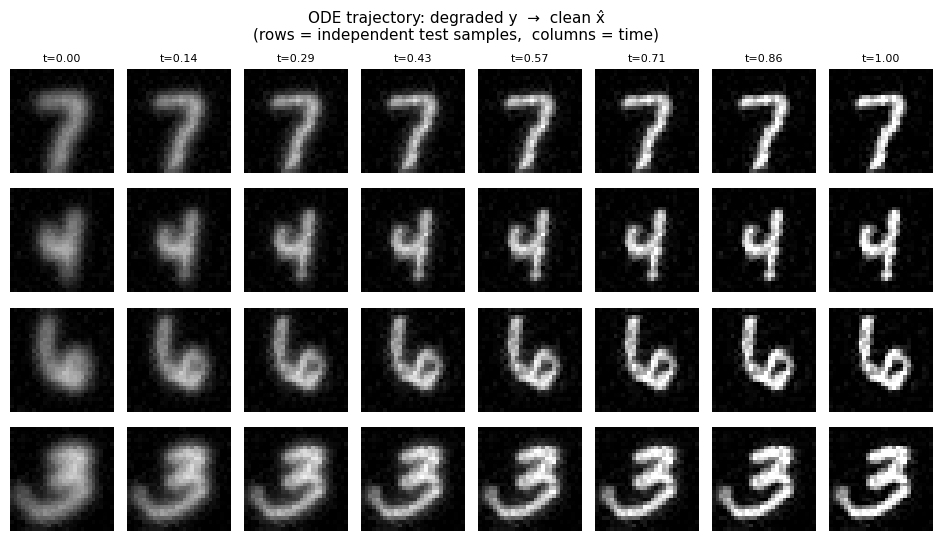

In [7]:
N_TRAJ   = 4
N_FRAMES = 8

trajectories = np.stack([
    np.asarray(
        sample_bridge_trajectory(
            trained_model, jnp.array(y_test_np[i]), n_frames=N_FRAMES, dt0=dt0
        )
    )
    for i in range(N_TRAJ)
])  # (N_TRAJ, N_FRAMES, 1, 28, 28)

ts_labels = np.linspace(0.0, 1.0, N_FRAMES)

fig, axes = plt.subplots(
    N_TRAJ, N_FRAMES, figsize=(N_FRAMES * 1.5, N_TRAJ * 1.5),
    gridspec_kw={"wspace": 0.05, "hspace": 0.15},
)
for row, traj in enumerate(trajectories):
    for col, (frame, t_val) in enumerate(zip(traj, ts_labels)):
        ax = axes[row, col]
        ax.imshow(to_disp(frame[0]), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"t={t_val:.2f}", fontsize=8)

fig.suptitle(
    "ODE trajectory: degraded y  →  clean x̂\n"
    "(rows = independent test samples,  columns = time)",
    fontsize=11,
)
plt.show()

### 4c. Posterior samples — multiple draws from p(x | y)

The bridge model is **stochastic at training time** (different OT pairings, different noise
realisations in y).  However, with a fixed trained model and fixed y as initial condition,
the ODE is deterministic — you get the same x̂ every time.

To get diverse posterior samples, we add a small jitter to y before each ODE run,
simulating different noise realisations of the same observation.

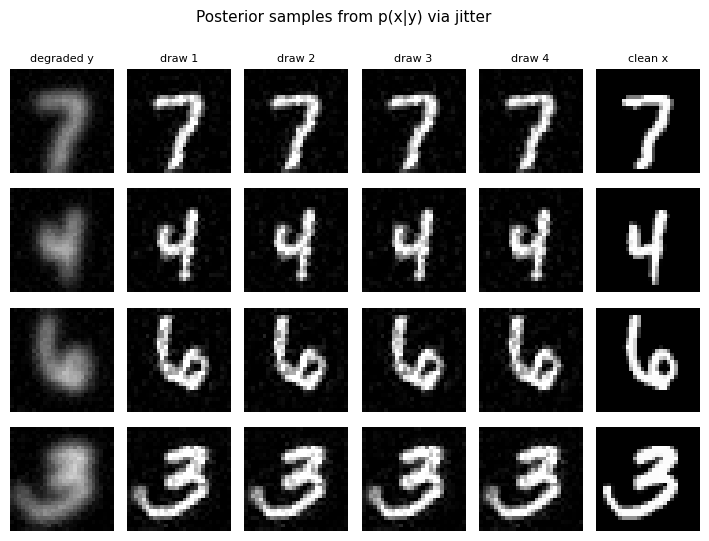

In [9]:
N_OBS     = 4   # test observations
N_SAMPLES = 4   # posterior draws per observation

posterior_key, key = jr.split(key)
jitter_keys = jr.split(posterior_key, N_OBS * N_SAMPLES).reshape(N_OBS, N_SAMPLES, 2)

fig, axes = plt.subplots(
    N_OBS, N_SAMPLES + 2,
    figsize=((N_SAMPLES + 2) * 1.5, N_OBS * 1.5),
    gridspec_kw={"wspace": 0.05, "hspace": 0.15},
)

for row in range(N_OBS):
    y_i  = jnp.array(y_test_np[row])    # (1,28,28)
    x1_i = x1_test_np[row]

    # Column 0: degraded input
    axes[row, 0].imshow(to_disp(y_test_np[row][0]), cmap="gray", vmin=0, vmax=1)
    axes[row, 0].axis("off")
    if row == 0:
        axes[row, 0].set_title("degraded y", fontsize=8)

    # Columns 1..N_SAMPLES: posterior draws
    for s in range(N_SAMPLES):
        # Small noise jitter to get sample diversity
        jitter = 0.02 * jax.random.normal(jitter_keys[row, s], y_i.shape)
        y_jit  = jnp.clip(y_i + jitter, -1.0, 1.0)
        xhat   = sample_bridge(trained_model, y_jit, solver, dt0, t0, t1, controller)
        axes[row, s + 1].imshow(to_disp(np.asarray(xhat)[0]), cmap="gray", vmin=0, vmax=1)
        axes[row, s + 1].axis("off")
        if row == 0:
            axes[row, s + 1].set_title(f"draw {s+1}", fontsize=8)

    # Last column: ground truth
    axes[row, -1].imshow(to_disp(x1_i[0]), cmap="gray", vmin=0, vmax=1)
    axes[row, -1].axis("off")
    if row == 0:
        axes[row, -1].set_title("clean x", fontsize=8)

fig.suptitle("Posterior samples from p(x|y) via jitter", fontsize=11)
plt.show()

## 5. Quantitative Evaluation

We compute **PSNR** and **SSIM** on 100 test pairs for three methods:

| Method | Description |
|---|---|
| Degraded y | No reconstruction (baseline lower bound) |
| Wiener filter | Classical pseudo-inverse in frequency domain |
| Bridge FM | This model |

The Wiener filter is:
$$\hat{X} = \mathcal{F}^{-1}\left[\frac{H^* \cdot Y}{|H|^2 + \sigma^2_{\text{noise}}/\sigma^2_{\text{signal}}}\right]$$
where $H$ is the DFT of the blur kernel.

In [11]:
from scipy.ndimage import gaussian_filter
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim


def wiener_deblur(y_np: np.ndarray, sigma_blur: float, sigma_noise: float,
                  sigma_signal: float = 0.5) -> np.ndarray:
    """Per-image Wiener filter in the Fourier domain.

    Args:
        y_np:         Degraded image, shape (H, W), values in [-1, 1].
        sigma_blur:   Blur sigma used in the forward model.
        sigma_noise:  Noise sigma used in the forward model.
        sigma_signal: Assumed signal std (default 0.5 for normalised images).

    Returns:
        Wiener-filtered image of shape (H, W), clipped to [-1, 1].
    """
    H, W = y_np.shape
    # Build the PSF in pixel space and take its DFT
    psf = np.zeros((H, W), dtype=np.float64)
    psf[0, 0] = 1.0
    psf = gaussian_filter(psf, sigma=sigma_blur)
    H_f = np.fft.fft2(psf)

    Y_f = np.fft.fft2(y_np.astype(np.float64))
    snr_inv = (sigma_noise / sigma_signal) ** 2
    X_f = (np.conj(H_f) / (np.abs(H_f) ** 2 + snr_inv)) * Y_f
    x_hat = np.fft.ifft2(X_f).real
    return np.clip(x_hat, -1.0, 1.0).astype(np.float32)


# Evaluate on first 100 test images
N_EVAL = 100
test_iter = iter(testloader)
y_eval_list, x1_eval_list = [], []
while sum(len(b) for b in y_eval_list) < N_EVAL:
    yb, xb = next(test_iter)
    y_eval_list.append(yb.numpy())
    x1_eval_list.append(xb.numpy())

y_eval  = np.concatenate(y_eval_list)[:N_EVAL]   # (N_EVAL, 1, 28, 28)
x1_eval = np.concatenate(x1_eval_list)[:N_EVAL]

psnr_deg, psnr_wie, psnr_fm = [], [], []
ssim_deg, ssim_wie, ssim_fm  = [], [], []

for i in range(N_EVAL):
    x_true = x1_eval[i, 0]          # (28, 28)
    y_obs  = y_eval[i, 0]

    # Wiener
    x_wie = wiener_deblur(y_obs, SIGMA_BLUR, SIGMA_NOISE)

    # Bridge FM
    xhat = np.asarray(sample_bridge(
        trained_model, jnp.array(y_eval[i]), solver, dt0, t0, t1, controller
    ))[0]

    dr = (-1.0, 1.0)
    psnr_deg.append(psnr(x_true, y_obs,   data_range=2.0))
    psnr_wie.append(psnr(x_true, x_wie,   data_range=2.0))
    psnr_fm.append( psnr(x_true, xhat,    data_range=2.0))
    ssim_deg.append(ssim(x_true, y_obs,   data_range=2.0))
    ssim_wie.append(ssim(x_true, x_wie,   data_range=2.0))
    ssim_fm.append( ssim(x_true, xhat,    data_range=2.0))

print(f"{'Method':<18} {'PSNR (dB)':>10} {'SSIM':>8}")
print("-" * 38)
print(f"{'Degraded y':<18} {np.mean(psnr_deg):>10.2f} {np.mean(ssim_deg):>8.4f}")
print(f"{'Wiener filter':<18} {np.mean(psnr_wie):>10.2f} {np.mean(ssim_wie):>8.4f}")
print(f"{'Bridge FM':<18} {np.mean(psnr_fm):>10.2f} {np.mean(ssim_fm):>8.4f}")

Method              PSNR (dB)     SSIM
--------------------------------------
Degraded y              14.34   0.4586
Wiener filter           13.04   0.3235
Bridge FM               19.78   0.7903


### 5b. Ablation: PSNR vs blur and noise level

Sweep over $\sigma_{\text{blur}} \in \{1, 2, 3\}$ and $\sigma_{\text{noise}} \in \{0.01, 0.05, 0.1\}$.
A heavier blur or stronger noise makes the problem harder and should yield lower PSNR.

> **Note**: This cell evaluates the *current trained model* (trained at σ_blur=2, σ_noise=0.05)
> on data with different forward-model parameters — i.e. it tests robustness/mismatch.
> For a fair per-setting comparison you would retrain at each setting.

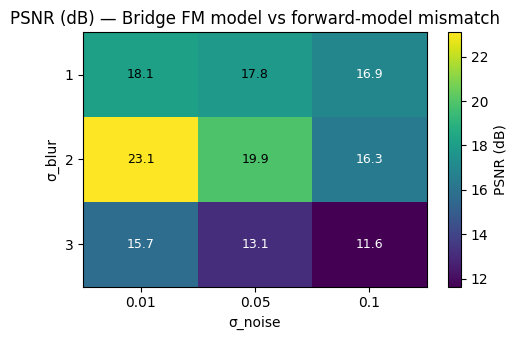

In [12]:
from src.data.mnist_inverse import BlurredMNIST
from torch.utils.data import DataLoader

sigma_blurs  = [1, 2, 3]
sigma_noises = [0.01, 0.05, 0.1]
N_ABL = 50

results = np.zeros((len(sigma_blurs), len(sigma_noises)))

for i, sb in enumerate(sigma_blurs):
    for j, sn in enumerate(sigma_noises):
        ds = BlurredMNIST(train=False, sigma_blur=sb, sigma_noise=sn, seed=42)
        loader = DataLoader(ds, batch_size=N_ABL, shuffle=False)
        yb, xb = next(iter(loader))
        y_abl  = yb.numpy()   # (N_ABL, 1, 28, 28)
        x1_abl = xb.numpy()

        scores = []
        for k in range(N_ABL):
            xhat = np.asarray(
                sample_bridge(trained_model, jnp.array(y_abl[k]), solver, dt0, t0, t1, controller)
            )[0]
            scores.append(psnr(x1_abl[k, 0], xhat, data_range=2.0))
        results[i, j] = np.mean(scores)

# Plot heatmap
fig, ax = plt.subplots(figsize=(5, 3.5))
im = ax.imshow(results, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(sigma_noises)))
ax.set_xticklabels([f"{s}" for s in sigma_noises])
ax.set_yticks(range(len(sigma_blurs)))
ax.set_yticklabels([f"{s}" for s in sigma_blurs])
ax.set_xlabel("σ_noise")
ax.set_ylabel("σ_blur")
ax.set_title("PSNR (dB) — Bridge FM model vs forward-model mismatch")
plt.colorbar(im, ax=ax, label="PSNR (dB)")
for i in range(len(sigma_blurs)):
    for j in range(len(sigma_noises)):
        ax.text(j, i, f"{results[i,j]:.1f}", ha="center", va="center",
                color="white" if results[i, j] < results.mean() else "black", fontsize=9)
plt.tight_layout()
plt.show()